<a href="https://colab.research.google.com/github/alexzilberberg1-ux/BAMS-Technology/blob/main/Guided_Lab_5_1_Completed_Neural_Network_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Guided Lab 5.1: Building a Simple Neural Network Model

**Course 02: Introduction to Machine Learning for Cybersecurity**  
**Module 05: Introduction to Neural Networks**

## Lab Goal
Build and evaluate a simple neural network using TensorFlow/Keras and the `creditcard.csv` dataset.

Target:
- `Class = 0` → Normal transaction
- `Class = 1` → Fraudulent transaction


## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Step 2: Load the Dataset

In [4]:
df = pd.read_csv("creditcard-5.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Step 3: Explore the Dataset

In [5]:
df = pd.read_csv("creditcard-5.csv")

print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df["Class"].value_counts())

print("\nClass distribution percentage:")
print(df["Class"].value_counts(normalize=True) * 100)

Dataset shape: (284807, 31)

Missing values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Class distribution percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


## Step 4: Define Features and Target

In [6]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (284807, 30)
Target shape: (284807,)


## Step 5: Split the Dataset

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (227845, 30)
Testing set shape: (56962, 30)


## Step 6: Scale the Data

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (227845, 30)
Scaled testing shape: (56962, 30)


## Step 7: Build a Simple Neural Network

In [9]:
model = Sequential([
    Dense(32, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

## Step 8: Compile the Model

In [10]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## Step 9: Train the Neural Network

In [11]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9982 - loss: 0.0149 - val_accuracy: 0.9994 - val_loss: 0.0033
Epoch 2/10
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9994 - loss: 0.0030 - val_accuracy: 0.9993 - val_loss: 0.0031
Epoch 3/10
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9995 - loss: 0.0027 - val_accuracy: 0.9995 - val_loss: 0.0029
Epoch 4/10
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9995 - loss: 0.0025 - val_accuracy: 0.9994 - val_loss: 0.0031
Epoch 5/10
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9995 - loss: 0.0023 - val_accuracy: 0.9994 - val_loss: 0.0030
Epoch 6/10
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9996 - loss: 0.0022 - val_accuracy: 0.9991 - val_loss: 0.0039


## Step 10: Visualize Training Performance

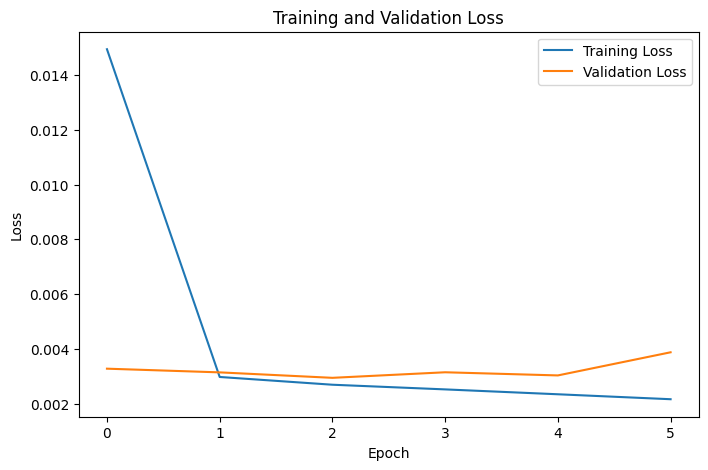

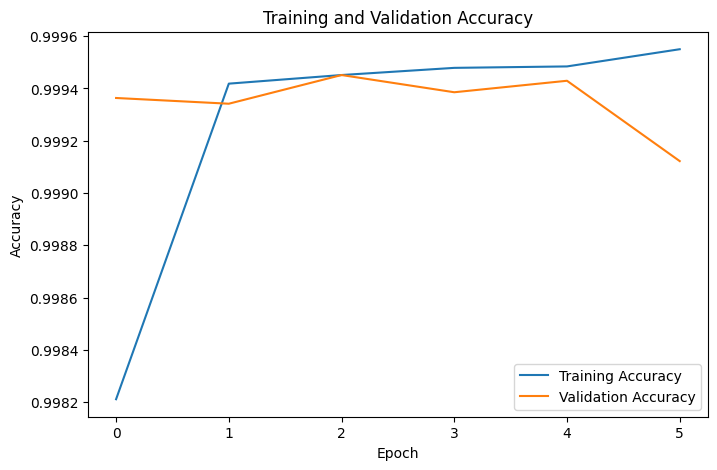

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Step 11: Generate Predictions

In [13]:
y_prob = model.predict(X_test_scaled)
y_pred = (y_prob > 0.5).astype(int).flatten()

print("First 10 predicted probabilities:")
print(y_prob[:10].flatten())

print("\nFirst 10 predicted classes:")
print(y_pred[:10])

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
First 10 predicted probabilities:
[4.9676487e-06 4.4942940e-06 3.0493837e-07 3.2524060e-06 3.8325496e-03
 7.8358717e-05 1.2752295e-06 5.6385429e-06 1.4911453e-05 2.0359510e-05]

First 10 predicted classes:
[0 0 0 0 0 0 0 0 0 0]


## Step 12: Evaluate the Neural Network

In [14]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.999403110845827
Precision: 0.8555555555555555
Recall: 0.7857142857142857
F1 Score: 0.8191489361702128

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.79      0.82        98

    accuracy                           1.00     56962
   macro avg       0.93      0.89      0.91     56962
weighted avg       1.00      1.00      1.00     56962



## Step 13: Confusion Matrix

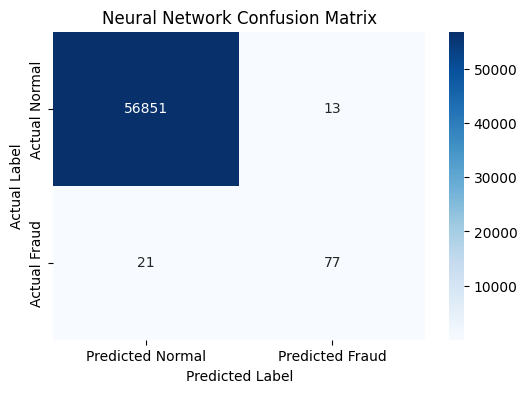

[[56851    13]
 [   21    77]]


In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Normal", "Predicted Fraud"],
    yticklabels=["Actual Normal", "Actual Fraud"]
)
plt.title("Neural Network Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

print(cm)

## Step 14: Adjust the Prediction Threshold

In [16]:
threshold = 0.3
y_pred_adjusted = (y_prob > threshold).astype(int).flatten()

print("Evaluation with threshold =", threshold)
print(classification_report(y_test, y_pred_adjusted, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_adjusted))

Evaluation with threshold = 0.3
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.77      0.84      0.80        98

    accuracy                           1.00     56962
   macro avg       0.89      0.92      0.90     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56840    24]
 [   16    82]]


## Step 15: Example Interpretation

This neural network was trained to classify transactions as normal or fraudulent. Because the dataset is highly imbalanced, accuracy alone may be misleading. Precision, recall, and F1 score provide more meaningful information.

- High precision means fewer normal transactions are incorrectly flagged as fraud.
- High recall means more actual fraud cases are detected.
- False negatives are risky because fraud may be missed.
- False positives can create unnecessary alerts.

Changing the threshold can change the balance between precision and recall.


## Reflection Questions

1. What was the model accuracy?
2. Why might accuracy alone be misleading for this dataset?
3. What do precision and recall tell us about fraud detection?
4. What does the confusion matrix show?
5. Did changing the prediction threshold affect model performance?
6. How can neural networks support cybersecurity and fraud detection?
7. What are some limitations of neural networks in cybersecurity applications?


## Reflection Questions Answers

1.  **What was the model accuracy?**
    The model accuracy was approximately `99.94%` (0.9994).

2.  **Why might accuracy alone be misleading for this dataset?**
    Accuracy alone can be misleading because the dataset is highly imbalanced. With only about `0.17%` of transactions being fraudulent, a model could achieve very high accuracy (e.g., 99.83%) by simply predicting all transactions as normal, but it would completely fail to detect any fraud.

3.  **What do precision and recall tell us about fraud detection?**
    *   **Precision** measures the proportion of correctly identified fraudulent transactions out of all transactions the model *predicted* as fraudulent. High precision means fewer false positives (normal transactions incorrectly flagged as fraud), which reduces unnecessary alerts or blocked legitimate transactions.
    *   **Recall** measures the proportion of correctly identified fraudulent transactions out of all *actual* fraudulent transactions. High recall means fewer false negatives (actual fraudulent transactions missed by the model), which is crucial to minimize financial losses from undetected fraud.

4.  **What does the confusion matrix show?**
    The confusion matrix (with the default threshold of 0.5) showed:
    *   **True Negatives (TN):** `56851` (correctly identified normal transactions)
    *   **False Positives (FP):** `13` (normal transactions incorrectly identified as fraud)
    *   **False Negatives (FN):** `21` (fraudulent transactions incorrectly identified as normal)
    *   **True Positives (TP):** `77` (correctly identified fraudulent transactions)

5.  **Did changing the prediction threshold affect model performance?**
    Yes, changing the prediction threshold significantly affected model performance. When the threshold was adjusted from `0.5` to `0.3`:
    *   **Recall increased** from `0.785` to `0.84`, meaning more fraudulent transactions were detected (from 77 to 82).
    *   **Precision decreased** from `0.855` to `0.77`, meaning more normal transactions were incorrectly flagged as fraud (from 13 to 24).
    This demonstrates a trade-off between precision and recall, where lowering the threshold makes the model more sensitive to fraud but also more prone to false alarms.

6.  **How can neural networks support cybersecurity and fraud detection?**
    Neural networks are highly effective in cybersecurity and fraud detection due to their ability to:
    *   **Identify complex patterns:** They can learn intricate, non-linear relationships and hidden patterns within large datasets that indicate anomalous or malicious behavior.
    *   **Handle high-dimensional data:** They can process a vast number of features, making them suitable for rich datasets common in security (e.g., network traffic, transaction details).
    *   **Adapt to evolving threats:** With continuous training, neural networks can learn from new data and adapt to new types of fraud or cyberattacks.
    *   **Automate detection:** They can provide real-time or near real-time detection, reducing the need for manual review and speeding up response times.

7.  **What are some limitations of neural networks in cybersecurity applications?**
    Despite their strengths, neural networks have limitations:
    *   **Interpretability (Black Box):** It can be difficult to understand *why* a neural network makes a particular decision, which is a major concern in auditing, compliance, and incident response where explanations are often required.
    *   **Data Requirements:** They typically require large amounts of high-quality, labeled data for effective training, which can be scarce for rare events like zero-day attacks or novel fraud schemes.
    *   **Computational Resources:** Training deep neural networks can be computationally intensive, requiring significant hardware and time.
    *   **Vulnerability to Adversarial Attacks:** Neural networks can be tricked by subtle, carefully crafted adversarial inputs that lead to misclassifications, posing a risk in security applications.

## Submission Checklist

- All code cells run without errors
- Dataset path is correct
- Neural network model is trained
- Training plots are displayed
- Evaluation metrics are displayed
- Confusion matrix is included
- Reflection questions are answered
- Completed `.ipynb` file is submitted in Canvas
